# preprocessing of all GB files

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import eccodes
import subprocess
import pandas as pd
import csv
import matplotlib.pyplot as plt
import logging
import cfgrib
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import re
from pathlib import Path
from utils.parameter_mapping import ParameterMapper


In [2]:
# # 设置环境变量
# eccodes_definition_path = r"D:\softwares\Anaconda\envs\myenv_new\Library\share\eccodes\definitions"
# os.environ['ECCODES_DEFINITION_PATH'] = eccodes_definition_path

## list all the variables

In [2]:
import eccodes
import pandas as pd
import os

# 定义 HARMONIE 参数映射表
HARMONIE_PARAMS = {
    1: {'shortName': ['PMSL', 'PSRF'], 'name': ['Pressure altitude above MSL', 'Pressure height above ground'], 'units': 'Pa'},
    6: {'shortName': 'GEOP', 'name': 'Geopotential', 'units': 'm²/s²'},
    11: {'shortName': 'TMP', 'name': 'Temperature', 'units': 'K'},
    17: {'shortName': '2TD', 'name': 'Dew-point temperature 2m', 'units': 'K'},
    20: {'shortName': 'VIS', 'name': 'Visibility', 'units': 'm'},
    33: {'shortName': 'UGRD', 'name': 'U-component of wind', 'units': 'm/s'},
    34: {'shortName': 'VGRD', 'name': 'V-component of wind', 'units': 'm/s'},
    40: {'shortName': 'VVEL', 'name': 'Vertical velocity', 'units': 'm/s'},
    41: {'shortName': 'ABSV', 'name': 'Absolute vorticity', 'units': 's⁻¹'},
    52: {'shortName': 'RH', 'name': 'Relative humidity', 'units': '%'},
    65: {'shortName': 'WEASD', 'name': 'Water equivalent of snow', 'units': 'kg/m²'},
    71: {'shortName': 'TCC', 'name': 'Total cloud cover', 'units': '%'},
    73: {'shortName': 'LCC', 'name': 'Low cloud cover', 'units': '%'},
    74: {'shortName': 'MCC', 'name': 'Medium cloud cover', 'units': '%'},
    75: {'shortName': 'HCC', 'name': 'High cloud cover', 'units': '%'},
    115: {'shortName': 'SWR', 'name': 'Net shortwave radiation', 'units': 'J/m²'},
    116: {'shortName': 'LWR', 'name': 'Net longwave radiation', 'units': 'J/m²'},
    117: {'shortName': 'GRAD', 'name': 'Global radiation flux', 'units': 'W/m²'},
    121: {'shortName': 'MX2T', 'name': 'Maximum temperature 2m', 'units': 'K'},
    122: {'shortName': 'MN2T', 'name': 'Minimum temperature 2m', 'units': 'K'},
    160: {'shortName': 'CAPE', 'name': 'Convective available potential energy', 'units': 'J/kg'},
    161: {'shortName': 'CIN', 'name': 'Convective inhibition', 'units': 'J/kg'},
    162: {'shortName': 'CSULF', 'name': 'U-momentum of gusts', 'units': 'm/s'},
    163: {'shortName': 'CSDLF', 'name': 'V-momentum of gusts', 'units': 'm/s'},
    165: {'shortName': 'BLH', 'name': 'Boundary layer height', 'units': 'm'},
    181: {'shortName': 'LPSX', 'name': 'Rain', 'units': 'kg/m²'},
    184: {'shortName': 'HGTY', 'name': 'Snow', 'units': 'kg/m²'},
    186: {'shortName': 'ICNG', 'name': 'Cloud base', 'units': 'm'},
    187: {'shortName': 'CEIL', 'name': 'Cloud ceiling', 'units': 'm'},
    201: {'shortName': 'ICWAT', 'name': 'Graupel', 'units': 'kg/m²'},
    209: {'shortName': 'TWATER', 'name': 'Total column water', 'units': 'kg/m²'}
}

def list_grib_variables(grib_path):
    """
    列出 GRIB 文件中所有的变量及其详细信息。
    
    参数：
    - grib_path (str): GRIB 文件的路径
    
    返回：
    - pandas.DataFrame: 包含变量信息的表格
    """
    variables = []
    
    if not os.path.exists(grib_path):
        raise FileNotFoundError(f"GRIB 文件未找到: {grib_path}")
    
    with open(grib_path, 'rb') as f:
        while True:
            gid = eccodes.codes_grib_new_from_file(f)
            if gid is None:
                break
            
            try:
                var_code = eccodes.codes_get(gid, 'indicatorOfParameter')
                level_type = eccodes.codes_get(gid, 'indicatorOfTypeOfLevel')
                level = eccodes.codes_get(gid, 'level')
                tri = eccodes.codes_get(gid, 'timeRangeIndicator')
                
                # 从映射表获取参数信息
                param_info = HARMONIE_PARAMS.get(var_code, {
                    'shortName': 'unknown',
                    'name': 'unknown',
                    'units': 'unknown'
                })
                
                # 处理可能的列表形式的 shortName 和 name
                short_name = param_info['shortName']
                if isinstance(short_name, list):
                    # 根据 level_type 选择适当的名称
                    short_name = short_name[1] if level_type in ['105', 'sfc'] else short_name[0]
                
                name = param_info['name']
                if isinstance(name, list):
                    name = name[1] if level_type in ['105', 'sfc'] else name[0]
                
                # 标准化 level_type
                if level_type == '100':
                    level_type = 'pl'
                elif level_type in ['103', '105']:
                    level_type = 'sfc'
                
                variables.append({
                    'Code': var_code,
                    'Short_name': short_name,
                    'Description': name,
                    'Units': param_info['units'],
                    'Leveltype': level_type,
                    'Level': level,
                    'TRI': tri
                })
                
            except Exception as e:
                print(f"Error processing message: {e}")
            finally:
                eccodes.codes_release(gid)
    
    df = pd.DataFrame(variables)
    df_unique = df.drop_duplicates()
    
    return df_unique

# 使用示例
grib_path = "HARMONIE_AROME_meteo_24hrs/mbr000/fc2024070912+001GB_UWCW01_N20e"
variables_df = list_grib_variables(grib_path)

# 设置显示选项
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
# 按照Code排序
variables_df = variables_df.sort_values('Code')

print(variables_df)
print(variables_df.to_string())

# # 保存为CSV文件
# output_path = "harmonie_variables.csv"
# variables_df.to_csv(output_path, index=False, encoding='utf-8')
# print(f"\nCSV文件已保存到: {output_path}")

# # 显示基本统计信息
# print(f"\n总共发现 {len(variables_df)} 个不同的变量")
# print("\n层级类型统计：")
# print(variables_df['Leveltype'].value_counts())


    Code Short_name                            Description  Units Leveltype  \
0      1       PMSL            Pressure altitude above MSL     Pa       sfc   
1      6       GEOP                           Geopotential  m²/s²        pl   
2     11        TMP                            Temperature      K        pl   
3     11        TMP                            Temperature      K       sfc   
4     11        TMP                            Temperature      K       sfc   
5     20        VIS                             Visibility      m       sfc   
6     33       UGRD                    U-component of wind    m/s        pl   
8     33       UGRD                    U-component of wind    m/s       sfc   
14    33       UGRD                    U-component of wind    m/s       sfc   
10    33       UGRD                    U-component of wind    m/s       sfc   
12    33       UGRD                    U-component of wind    m/s       sfc   
7     34       VGRD                    V-component o

## choose the proper parameters to simulate the precipitation system

### extract 4 layers for future wind direction cal and rain cal

In [3]:
from utils.grib_utils import extract_and_merge_layers

# wind_layers = [
#         {
#             'shortName': 'UGRD',
#             'level': 10,
#             'levelType': 'sfc'
#         },
#         {
#             'shortName': 'VGRD',
#             'level': 10,
#             'levelType': 'sfc'
#         }
#     ]

# input_path = "HARMONIE_AROME_meteo/mbr000/fc2024070912+001GB_UWCW01_N20e"
# output_base = "extracted_data"
# extract_and_merge_layers(
#         input_path,
#         f"{output_base}/surface_wind.grb",
#         wind_layers
#     )



layers_to_extract = [
    {
        'shortName': 'UGRD',
        'level': 10,
        'levelType': 'sfc'
    },
    {
        'shortName': 'VGRD',
        'level': 10,
        'levelType': 'sfc'
    },
    {
        'shortName': 'LPSX',
        'level': 0,
        'levelType': 'sfc',
        'tri': 4
    },
    {
        'shortName': 'LPSX',
        'level': 0,
        'levelType': 'sfc',
        'tri': 0
    }
]

input_path = "HARMONIE_AROME_meteo_24hrs/mbr000/fc2024070912+001GB_UWCW01_N20e"
output_path = "extracted_data/fc2024070912+001GB_UWCW01_N20e_selected.grb"

extract_and_merge_layers(input_path, output_path,layers_to_extract)

Processing file: HARMONIE_AROME_meteo_24hrs/mbr000/fc2024070912+001GB_UWCW01_N20e

Found matching message:
  Parameter: UGRD (code: 33)
  Level: 10 sfc
  TRI: 0 (instant)

Found matching message:
  Parameter: VGRD (code: 34)
  Level: 10 sfc
  TRI: 0 (instant)

Found matching message:
  Parameter: LPSX (code: 181)
  Level: 0 sfc
  TRI: 0 (instant)

Found matching message:
  Parameter: LPSX (code: 181)
  Level: 0 sfc
  TRI: 4 (accumulated_total)

Created: extracted_data/fc2024070912+001GB_UWCW01_N20e_selected.grb
Selected 4 of 4 layers


### extract for all grib files the same 4 layers

In [4]:
def extract_multiple_timesteps(base_dir: str, output_dir: str, layers_to_extract: list):
    """
    Extract specified layers from multiple timestep files
    从多个时间步长文件中提取指定图层

    Args:
        base_dir (str): Base directory containing input files
        output_dir (str): Directory for output files
        layers_to_extract (list): List of layer specifications to extract
    """
    # Create output directory if it doesn't exist
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Define timesteps (000 to 024)
    timesteps = [f"{i:03d}" for i in range(25)]  # 000 to 024

    for timestep in timesteps:
        # Construct input filename
        input_filename = f"fc2024070912+{timestep}GB_UWCW01_N20e"
        input_path = os.path.join(base_dir, "mbr000", input_filename)

        # Construct output filename
        output_filename = f"fc2024070912+{timestep}GB_UWCW01_N20e_selected.grb"
        output_path = os.path.join(output_dir, output_filename)

        # Check if input file exists
        if not os.path.exists(input_path):
            print(f"Warning: Input file not found: {input_path}")
            continue

        print(f"\nProcessing timestep {timestep}:")
        print(f"Input: {input_path}")
        print(f"Output: {output_path}")

        try:
            # Extract layers for this timestep
            extract_and_merge_layers(input_path, output_path, layers_to_extract)
            print(f"Successfully processed timestep {timestep}")
        except Exception as e:
            print(f"Error processing timestep {timestep}: {e}")

# Define your layers to extract
layers_to_extract = [
    # 10m wind (surface level)
    {
        'shortName': 'UGRD',
        'level': 10,
        'levelType': 'sfc'
    },
    {
        'shortName': 'VGRD',
        'level': 10,
        'levelType': 'sfc'
    },
    
    # 100m wind
    {
        'shortName': 'UGRD',
        'level': 100,
        'levelType': 'sfc'
    },
    {
        'shortName': 'VGRD',
        'level': 100,
        'levelType': 'sfc'
    },
    
    # 200m wind
    {
        'shortName': 'UGRD',
        'level': 200,
        'levelType': 'sfc'
    },
    {
        'shortName': 'VGRD',
        'level': 200,
        'levelType': 'sfc'
    },
    
    # 300m wind
    {
        'shortName': 'UGRD',
        'level': 300,
        'levelType': 'sfc'
    },
    {
        'shortName': 'VGRD',
        'level': 300,
        'levelType': 'sfc'
    },
    
    # Rainfall data
    {
        'shortName': 'LPSX',
        'level': 0,
        'levelType': 'sfc',
        'tri': 4
    },
    {
        'shortName': 'LPSX',
        'level': 0,
        'levelType': 'sfc',
        'tri': 0
    }
]

# Define directories
base_dir = "HARMONIE_AROME_meteo_24hrs"
output_dir = os.path.join("HARMONIE_AROME_meteo_24hrs", "extracted_merged")

# Run the extraction
extract_multiple_timesteps(base_dir, output_dir, layers_to_extract)


Processing timestep 000:
Input: HARMONIE_AROME_meteo_24hrs\mbr000\fc2024070912+000GB_UWCW01_N20e
Output: HARMONIE_AROME_meteo_24hrs\extracted_merged\fc2024070912+000GB_UWCW01_N20e_selected.grb
Error processing timestep 000: name 'extract_and_merge_layers' is not defined

Processing timestep 001:
Input: HARMONIE_AROME_meteo_24hrs\mbr000\fc2024070912+001GB_UWCW01_N20e
Output: HARMONIE_AROME_meteo_24hrs\extracted_merged\fc2024070912+001GB_UWCW01_N20e_selected.grb
Error processing timestep 001: name 'extract_and_merge_layers' is not defined

Processing timestep 002:
Input: HARMONIE_AROME_meteo_24hrs\mbr000\fc2024070912+002GB_UWCW01_N20e
Output: HARMONIE_AROME_meteo_24hrs\extracted_merged\fc2024070912+002GB_UWCW01_N20e_selected.grb
Error processing timestep 002: name 'extract_and_merge_layers' is not defined

Processing timestep 003:
Input: HARMONIE_AROME_meteo_24hrs\mbr000\fc2024070912+003GB_UWCW01_N20e
Output: HARMONIE_AROME_meteo_24hrs\extracted_merged\fc2024070912+003GB_UWCW01_N20e_sel

## to establish a transformation method in order to do mapping

### one example for wind visualization

In [2]:
"""
Example of visualizing extracted GRIB data using parameter mapper
使用参数映射器的GRIB数据可视化示例
"""


In [4]:
def plot_wind_fields(data: list, output_dir: str, time_str: str = ""):
    """
    Plot wind fields at different heights using mapped data
    绘制不同高度的风场图
    
    Args:
        data: List of mapped parameter data
        output_dir: Directory to save output files
        time_str: Time string for file naming (optional)
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Define heights to process
    heights = 10
    
    for height in heights:
        try:
            # Find U and V components for current height
            u_data = next(d for d in data 
                         if d['parameter']['shortName'] == 'UGRD' 
                         and d['level']['value'] == height)
            v_data = next(d for d in data 
                         if d['parameter']['shortName'] == 'VGRD' 
                         and d['level']['value'] == height)
            
            # Create figure
            fig = plt.figure(figsize=(12, 8))
            ax = plt.axes(projection=ccrs.PlateCarree())
            
            # Add map features
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.BORDERS)
            ax.gridlines(draw_labels=True)
            
            # Calculate wind speed for coloring
            skip = 10
            u = u_data['data']['values'][::skip, ::skip]
            v = v_data['data']['values'][::skip, ::skip]
            wind_speed = np.sqrt(u**2 + v**2)
            
            # Plot wind vectors colored by speed
            q = ax.quiver(u_data['data']['lons'][::skip, ::skip],
                         u_data['data']['lats'][::skip, ::skip],
                         u, v,
                         wind_speed,
                         transform=ccrs.PlateCarree(),
                         cmap='viridis',
                         scale=100,  # Adjust this value to change arrow size
                         width=0.005)  # Adjust this value to change arrow width
            
            # Add colorbar
            plt.colorbar(q, label='Wind Speed (m/s)')
            
            # Set map extent
            ax.set_extent([
                u_data['data']['lons'].min(),
                u_data['data']['lons'].max(),
                u_data['data']['lats'].min(),
                u_data['data']['lats'].max()
            ])
            
            # Add title
            if time_str:
                plt.title(f"Wind Field at {height}m\n{time_str}")
            else:
                plt.title(f"Wind Field at {height}m")
            
            # Save plot
            # output_file = f"{output_dir}/wind_field_{height}m{time_str}.png"
            # plt.savefig(output_file, dpi=300, bbox_inches='tight')
            # plt.close()
            
            # print(f"Created wind field plot for {height}m: {output_file}")
            
        except StopIteration:
            print(f"Could not find wind data for height {height}m")
        except Exception as e:
            print(f"Error creating plot for height {height}m: {e}")



In [26]:
# Example usage:
def process_wind_fields(input_file: str):
    """Process wind fields for a single time step"""
    print(f"\nReading data from: {input_file}")
    
    # Extract time from filename (assuming format contains +XXXGB)
    time_match = re.search(r'\+(\d{3})GB', input_file)
    time_str = f"_+{time_match.group(1)}h" if time_match else ""
    
    # Read data
    data = ParameterMapper.read_grib_file(input_file)
    
    # Create visualization
    output_dir = "wind_fields"
    plot_wind_fields(data, output_dir, time_str)




Reading data from: HARMONIE_AROME_meteo_24hrs/extracted_merged/fc2024070912+000GB_UWCW01_N20e_selected.grb

Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 10 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: V-component of wind
  Short Name: VGRD
  Code: 34
  Units: m/s
  Level: 10 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 100 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: V-component of wind
  Short Name: VGRD
  Code: 34
  Units: m/s
  Level: 100 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: U-component of win

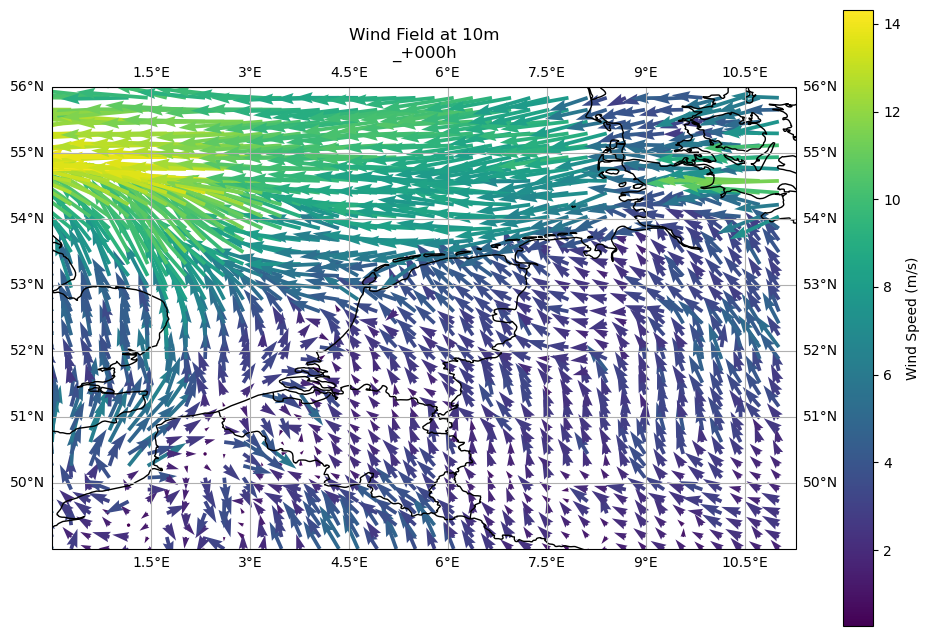

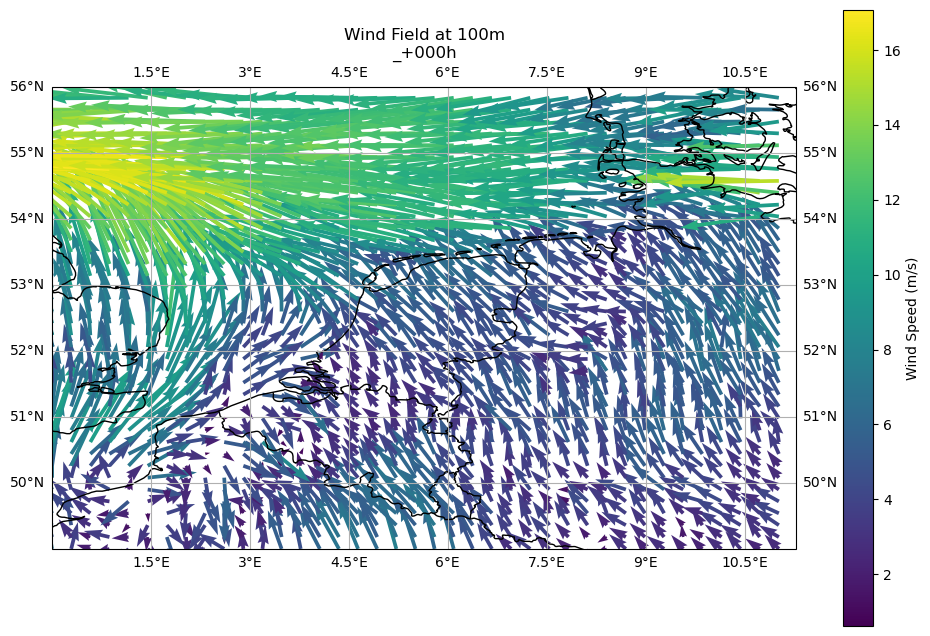

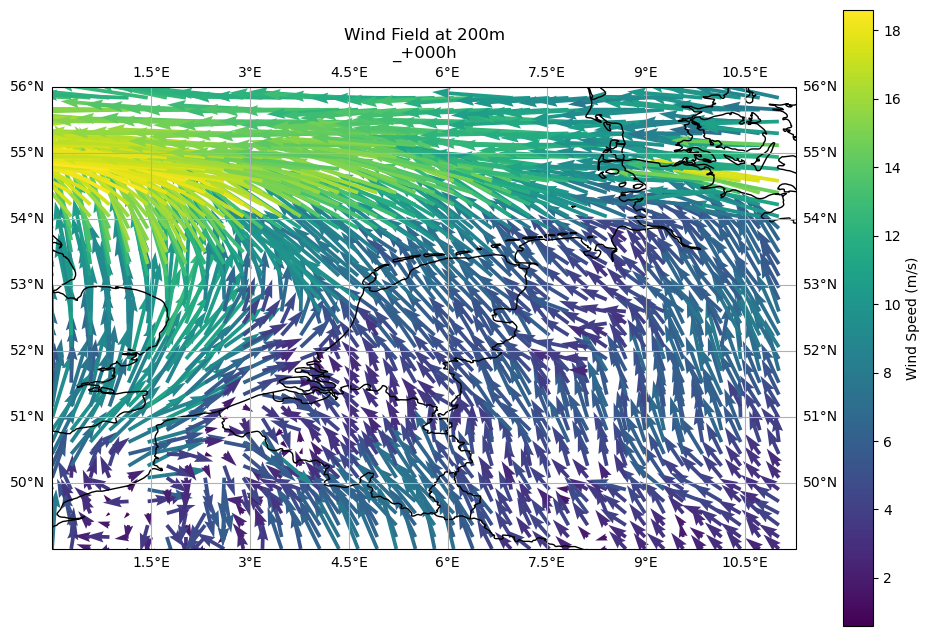

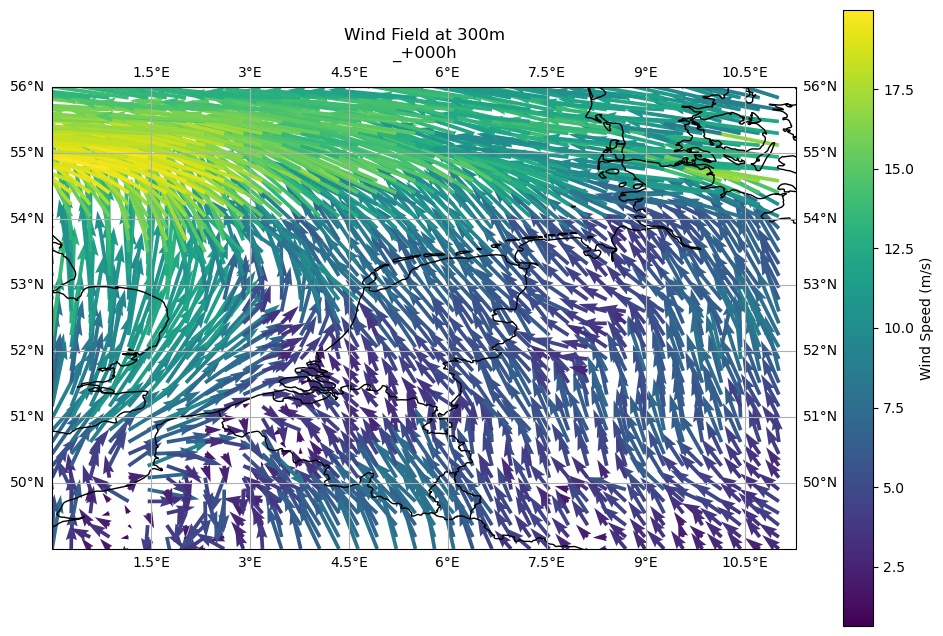

In [27]:
# Process a single file
input_file = "HARMONIE_AROME_meteo_24hrs/extracted_merged/fc2024070912+000GB_UWCW01_N20e_selected.grb"
process_wind_fields(input_file)



In [ ]:
# Or process all files in a directory
def process_all_wind_fields():
    """Process wind fields for all time steps"""
    input_dir = "HARMONIE_AROME_meteo_24hrs/extracted_merged"
    for file in sorted(os.listdir(input_dir)):
        if file.endswith("_selected.grb"):
            input_file = os.path.join(input_dir, file)
            process_wind_fields(input_file)

# Process all files
process_all_wind_fields()

### 计算两个步长间LPSX的差值，用于指代某小时内降雨量


Processing time period: 12:00 - 13:00

Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 10 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: V-component of wind
  Short Name: VGRD
  Code: 34
  Units: m/s
  Level: 10 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 100 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: V-component of wind
  Short Name: VGRD
  Code: 34
  Units: m/s
  Level: 100 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 200 (unknown)
 

C:\Users\96454\AppData\Local\Temp\ipykernel_32460\3147033546.py:48: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12, 8))



Parameter Information:
  Name: V-component of wind
  Short Name: VGRD
  Code: 34
  Units: m/s
  Level: 10 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 100 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: V-component of wind
  Short Name: VGRD
  Code: 34
  Units: m/s
  Level: 100 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 200 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: V-component of wind
  Short Name: VGRD
  Code: 34
  Units: m/s
  Level: 200 (unknown)
  Time Range: instant

Grid Information

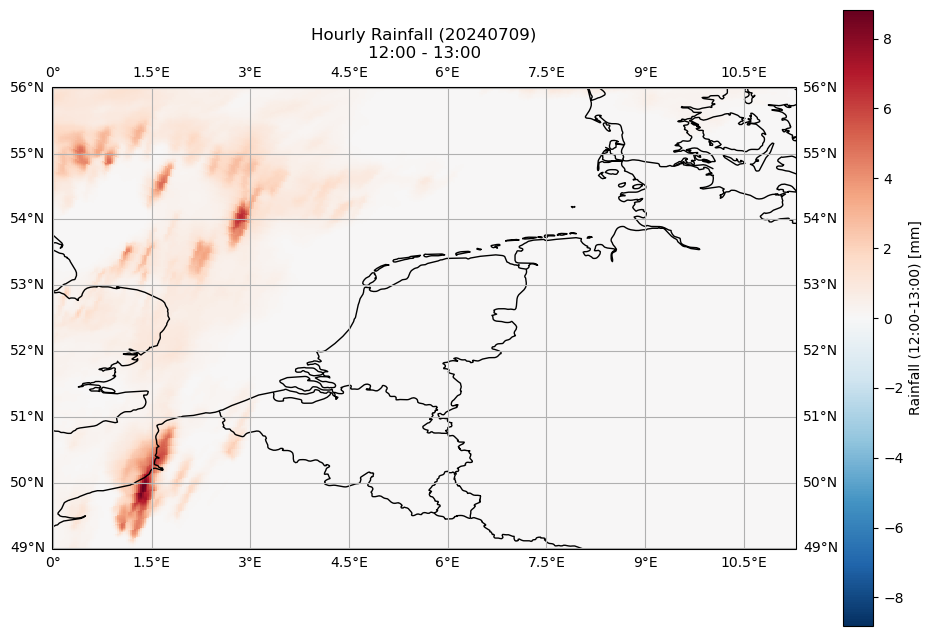

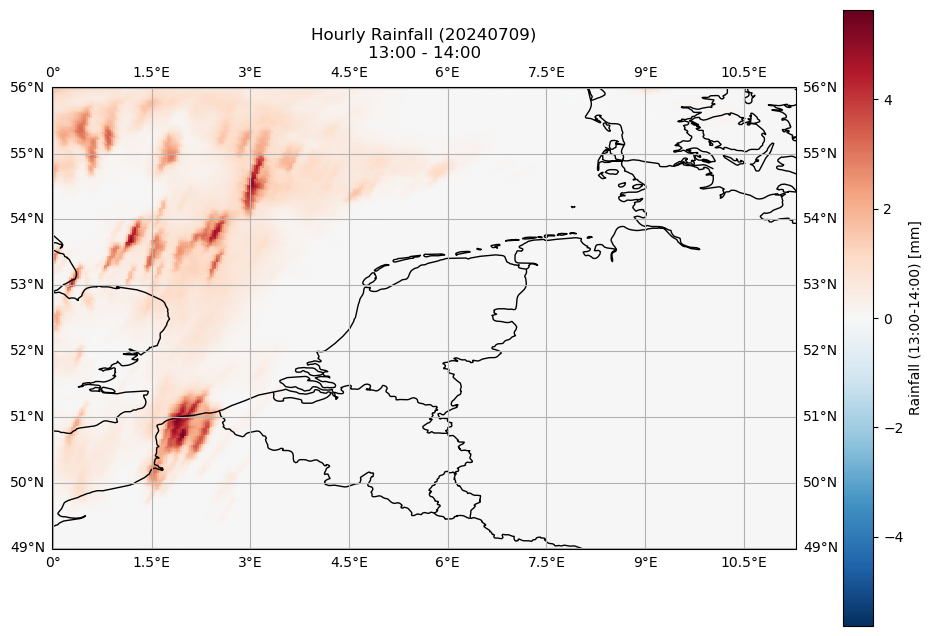

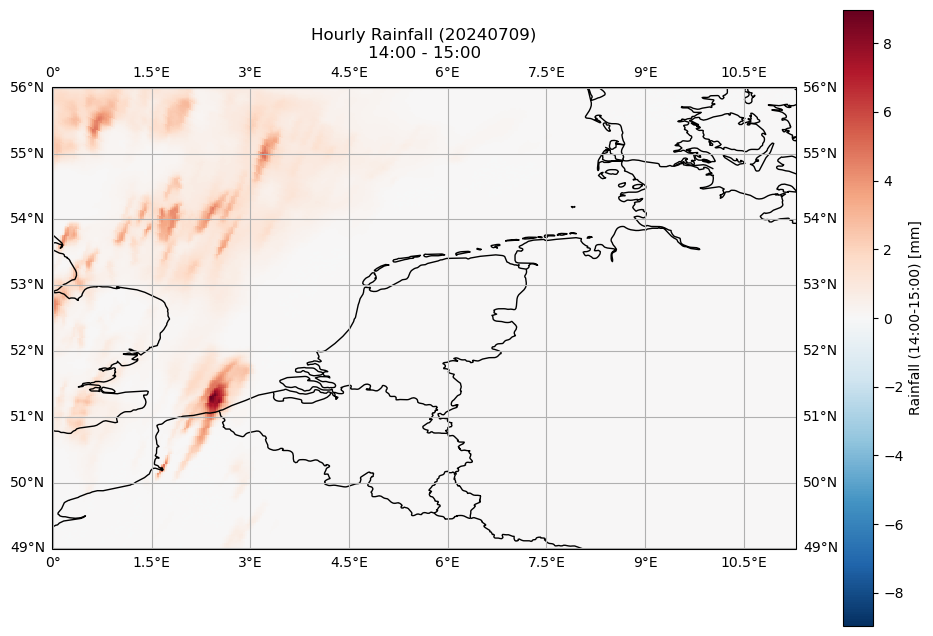

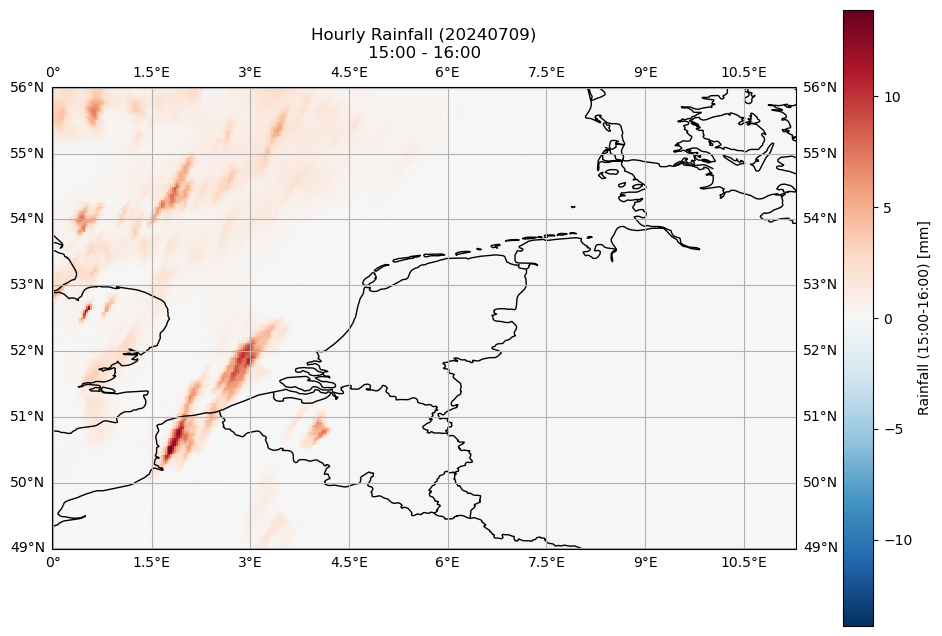

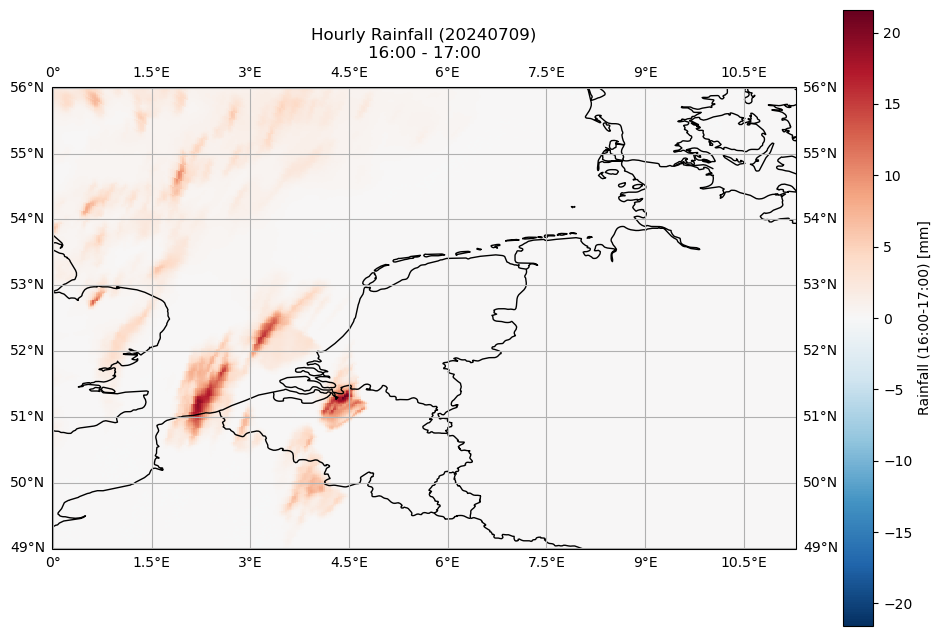

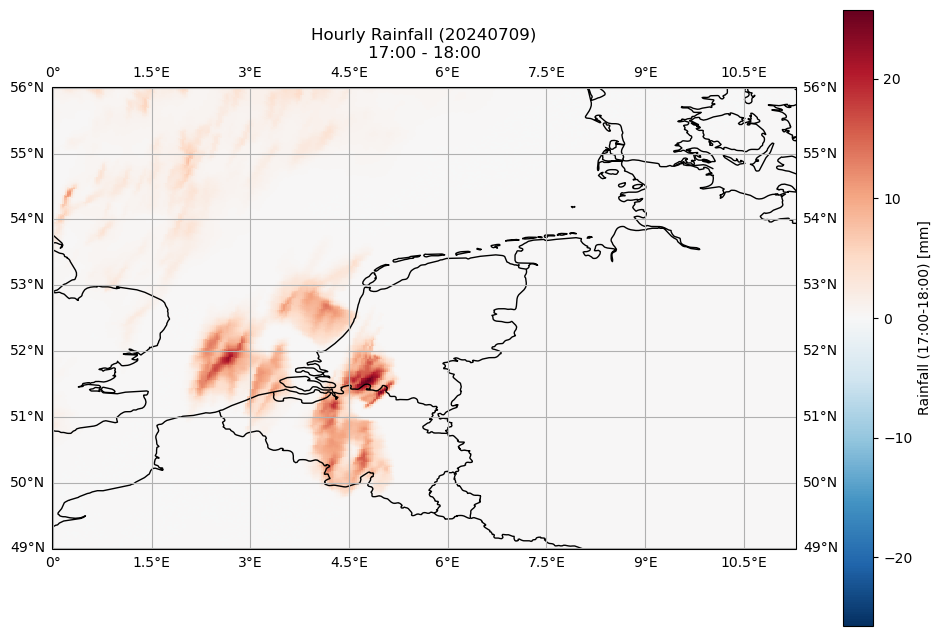

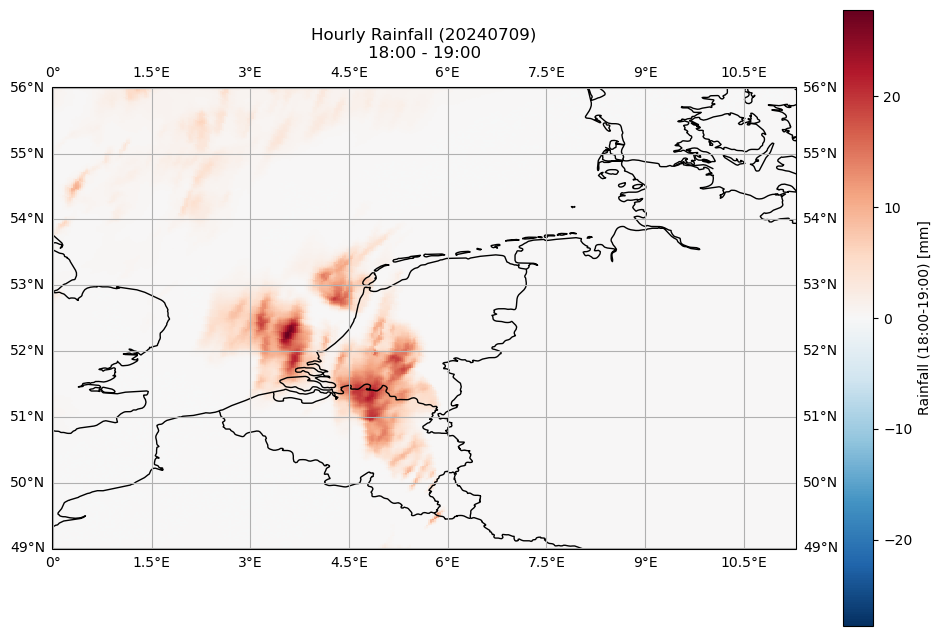

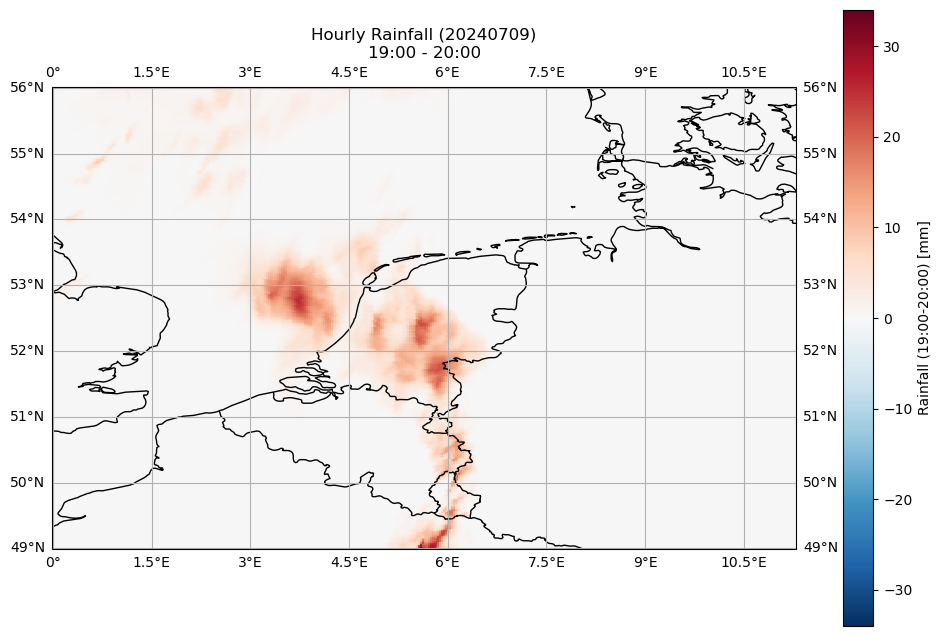

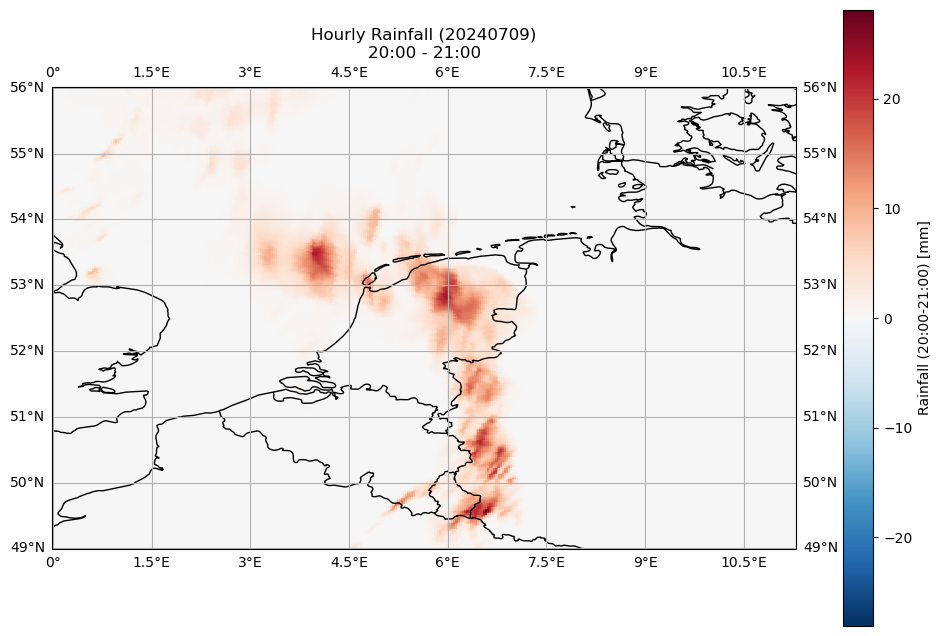

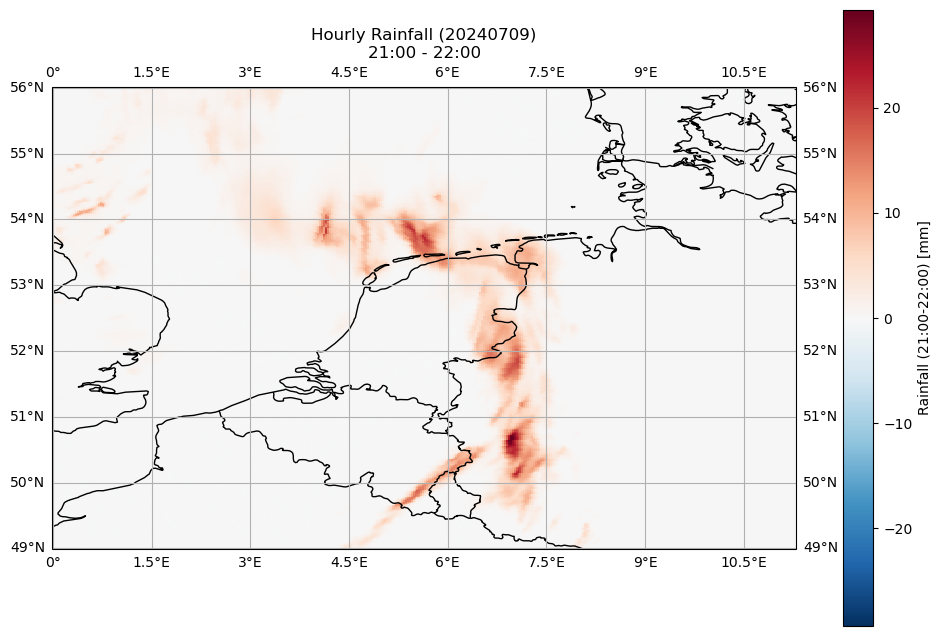

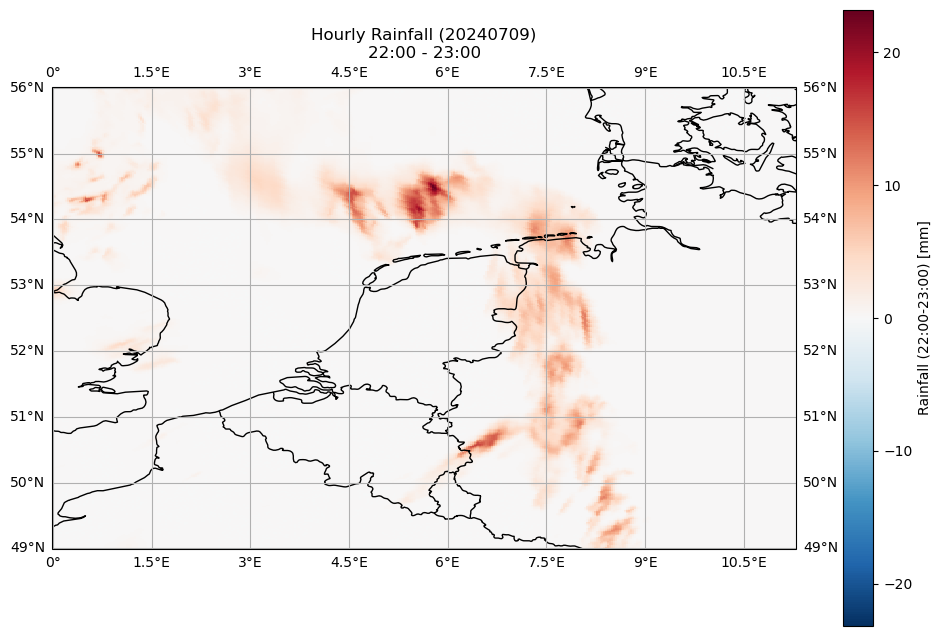

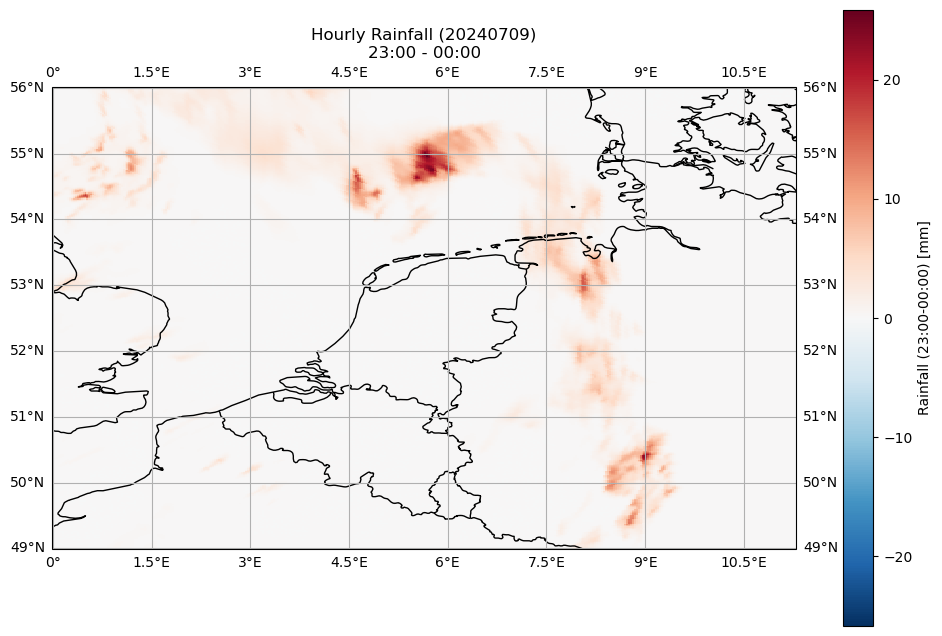

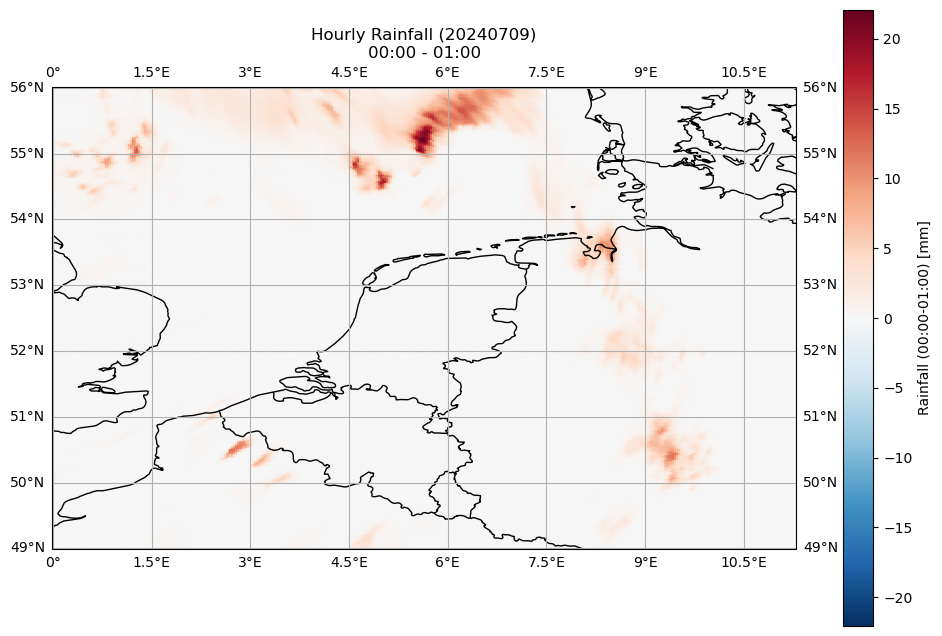

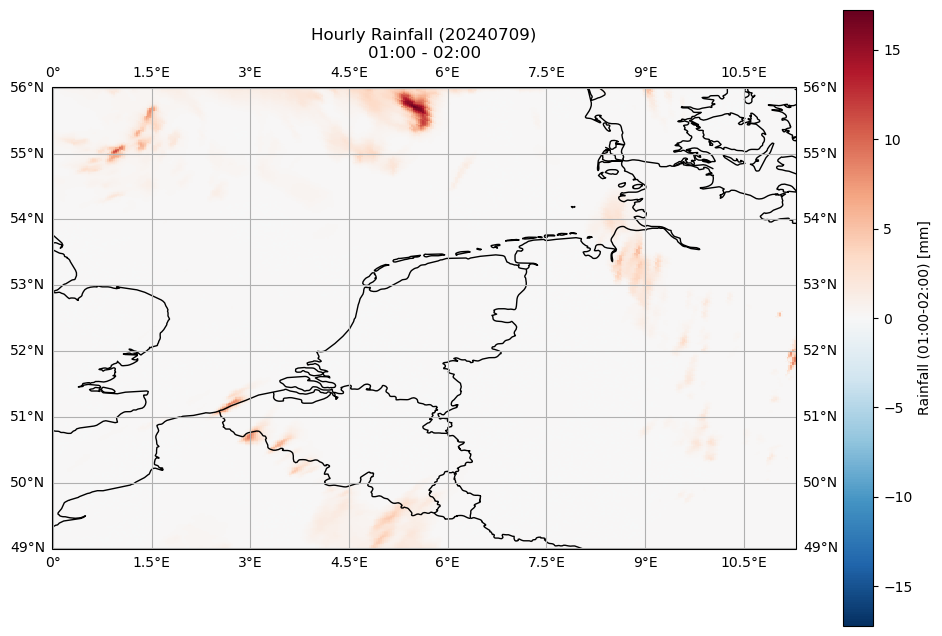

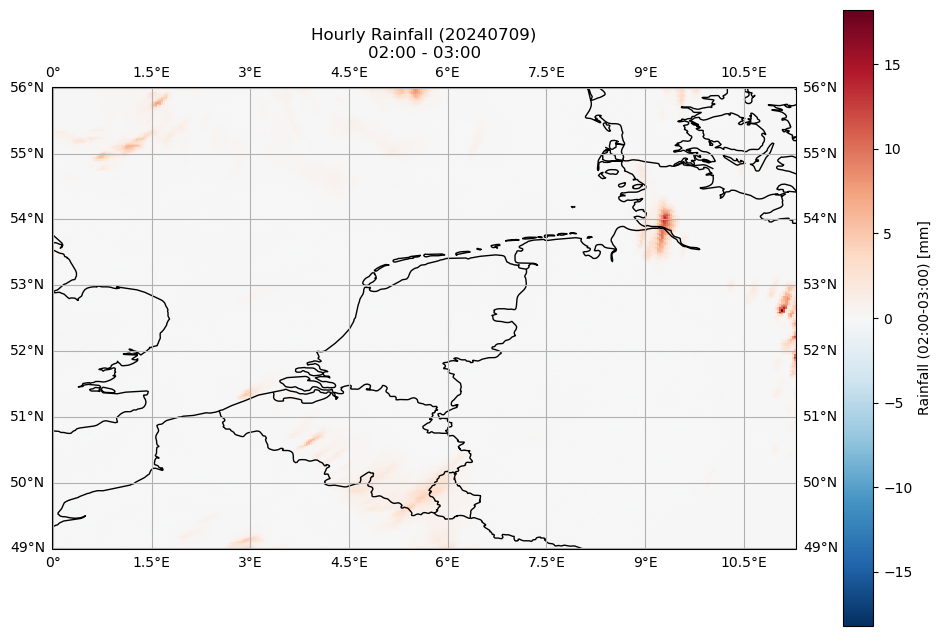

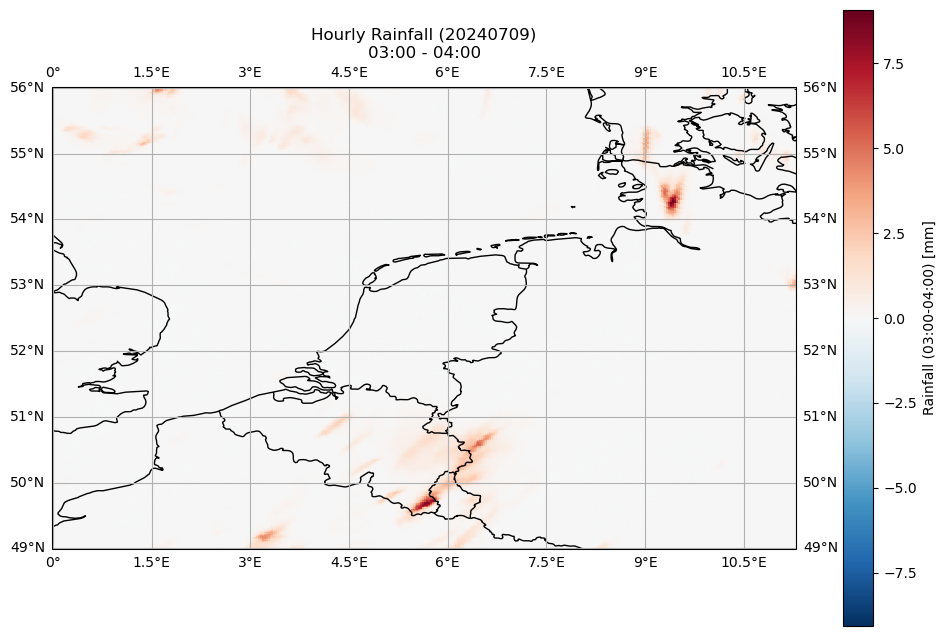

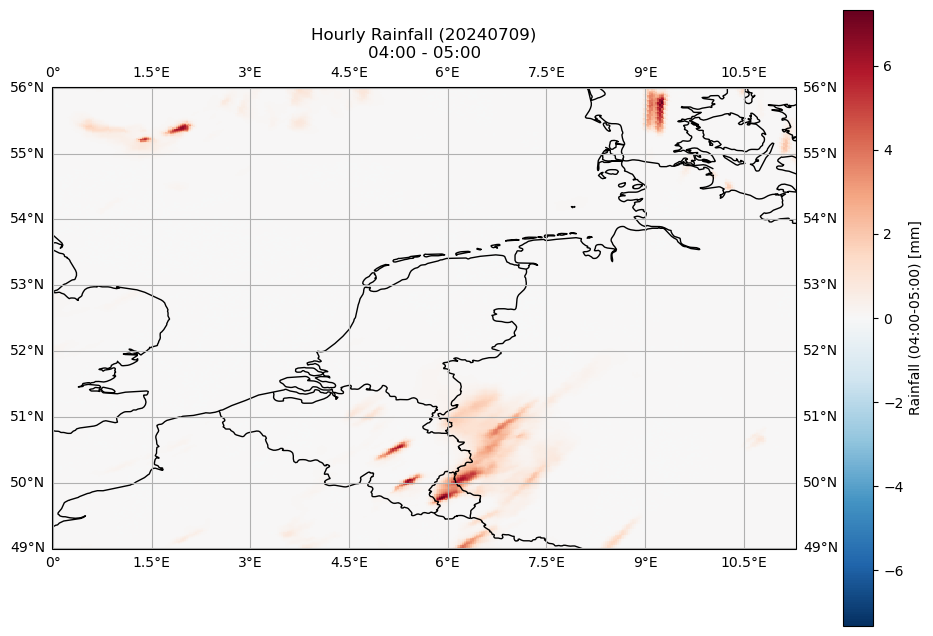

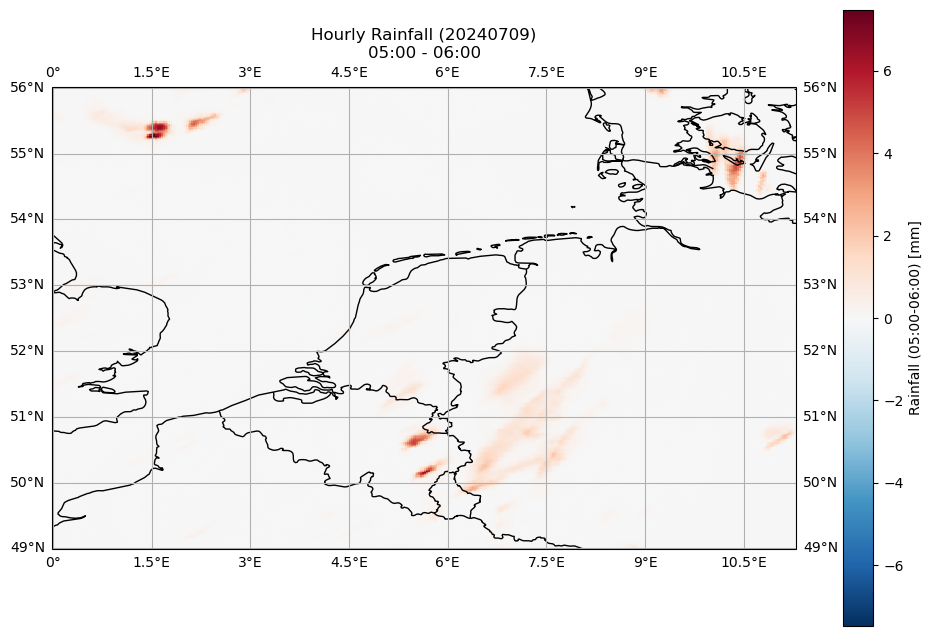

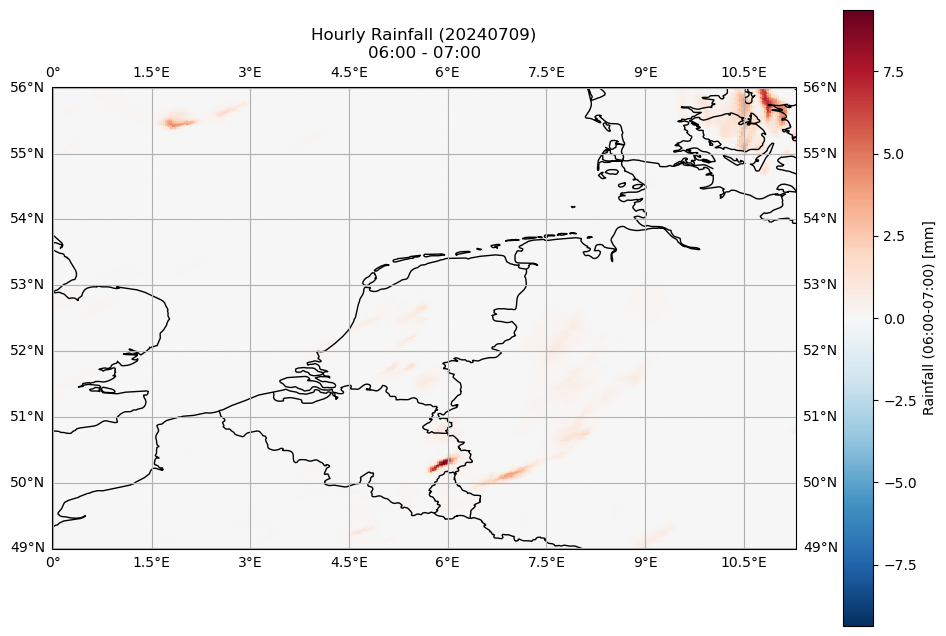

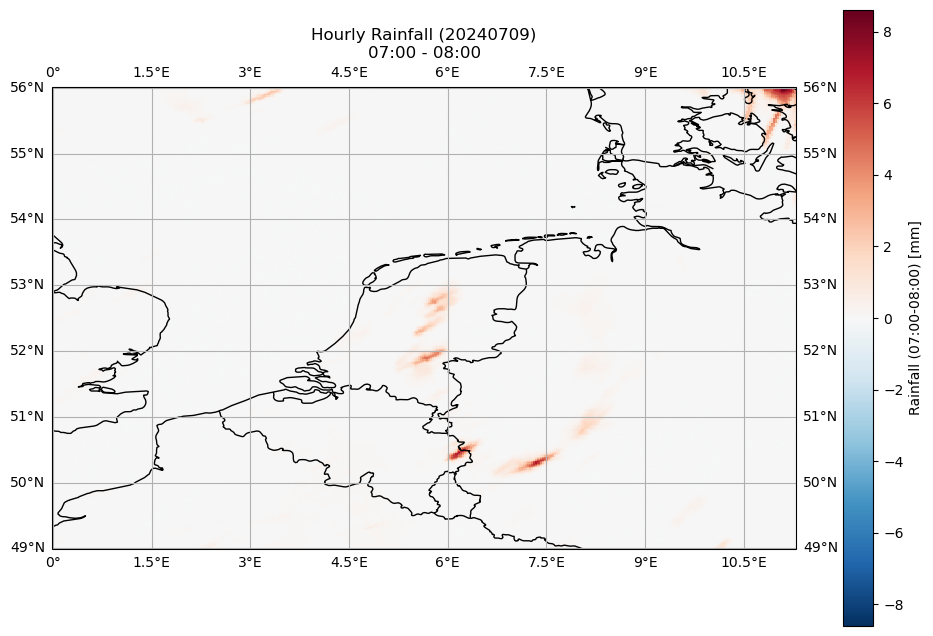

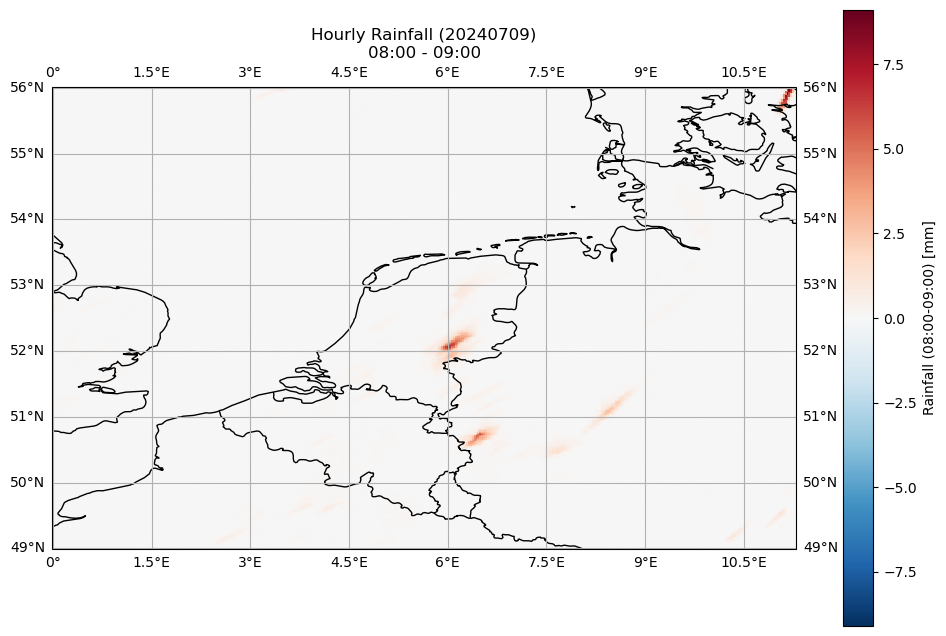

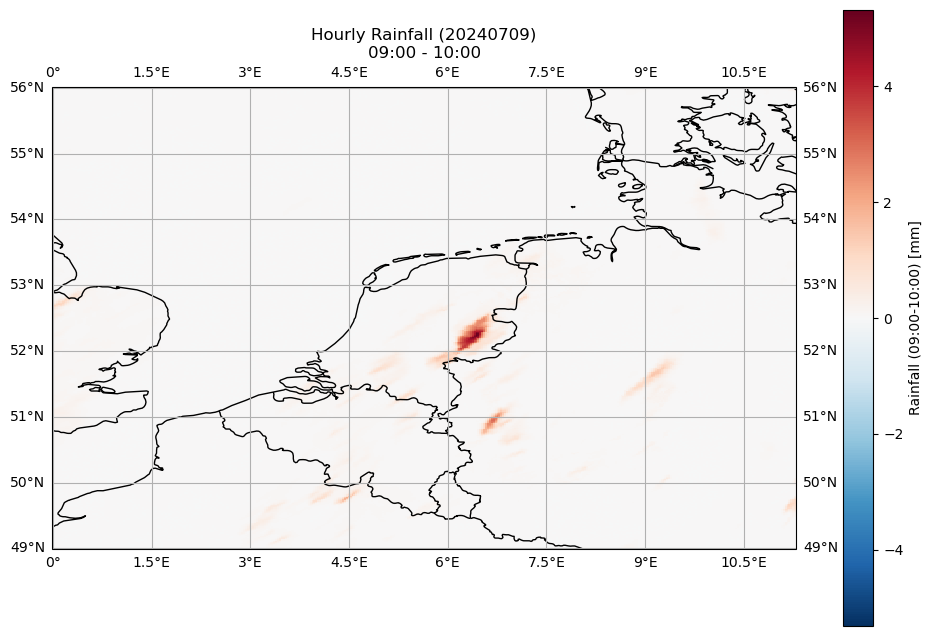

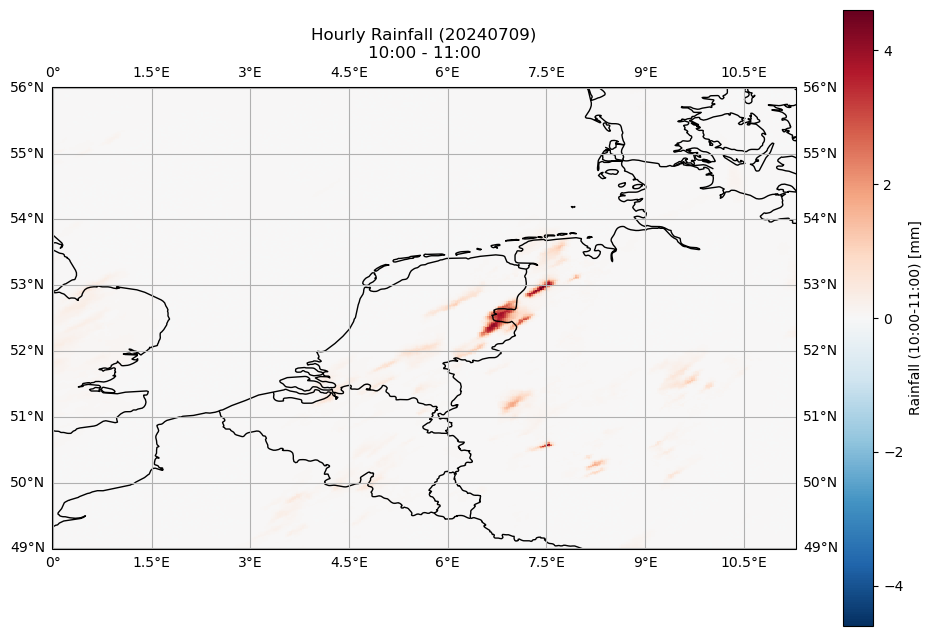

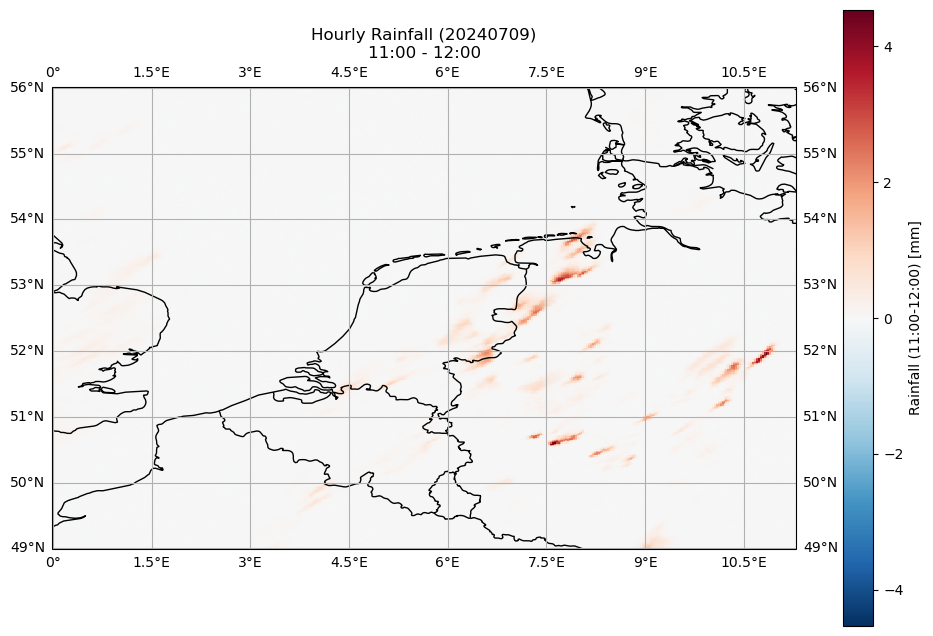

In [3]:
# 再对每隔文件进行循环，共计24个文件
def plot_24h_rainfall_differences(base_time: str = "2024070912", parameter: str = 'LPSX'):
    """
    Plot 24 hours of rainfall differences between consecutive timesteps
    绘制24小时内相邻时间步长的降水差值（从12:00开始）
    
    Args:
        base_time: Base time of forecast (YYYYMMDDHH format)
        parameter: Parameter to analyze (default: LPSX for rainfall)
    """
    base_path = "HARMONIE_AROME_meteo_24hrs/extracted_merged"
    output_path = f"{base_path}/rainfall_differences"
    os.makedirs(output_path, exist_ok=True)
    
    # Process 24 hours (from +000h to +024h)
    for hour in range(24):
        # Format current and next hour
        time1 = f"{hour:03d}"
        time2 = f"{hour+1:03d}"
        
        # Calculate actual time (starting from 12:00)
        actual_hour1 = (12 + hour) % 24
        actual_hour2 = (12 + hour + 1) % 24
        
        print(f"\nProcessing time period: {actual_hour1:02d}:00 - {actual_hour2:02d}:00")
        
        # Read both files
        file1 = f"{base_path}/fc{base_time}+{time1}GB_UWCW01_N20e_selected.grb"
        file2 = f"{base_path}/fc{base_time}+{time2}GB_UWCW01_N20e_selected.grb"
        
        try:
            # Read data from both files
            data1 = ParameterMapper.read_grib_file(file1)
            data2 = ParameterMapper.read_grib_file(file2)
            
            # Get accumulated values for both times
            param1 = next(d for d in data1 
                         if d['parameter']['shortName'] == parameter 
                         and d.get('timeRange', {}).get('indicator') == 4)
            param2 = next(d for d in data2 
                         if d['parameter']['shortName'] == parameter 
                         and d.get('timeRange', {}).get('indicator') == 4)
            
            # Calculate difference
            diff_values = param2['data']['values'] - param1['data']['values']
            
            # Create figure
            fig = plt.figure(figsize=(12, 8))
            ax = plt.axes(projection=ccrs.PlateCarree())
            
            # Add map features
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.BORDERS)
            ax.gridlines(draw_labels=True)
            
            # Plot difference
            im = ax.pcolormesh(
                param1['data']['lons'],
                param1['data']['lats'],
                diff_values,
                transform=ccrs.PlateCarree(),
                cmap='RdBu_r',
                vmin=-np.max(abs(diff_values)),
                vmax=np.max(abs(diff_values))
            )
            
            # Format time strings with actual hours
            time1_str = f"{actual_hour1:02d}:00"
            time2_str = f"{actual_hour2:02d}:00"
            
            # Add colorbar
            plt.colorbar(im, label=f"Rainfall ({time1_str}-{time2_str}) [{param1['parameter']['units']}]")
            
            # Add title
            date_str = f"{base_time[:8]}"  # Extract YYYYMMDD
            plt.title(f"Hourly Rainfall ({date_str})\n{time1_str} - {time2_str}")
            
            ## Save plot with actual time in filename
            # output_file = f"{output_path}/rainfall_{actual_hour1:02d}00_{actual_hour2:02d}00.png"
            # plt.savefig(output_file, dpi=300, bbox_inches='tight')
            # plt.close()
            
            # print(f"Created rainfall difference plot: {output_file}")
            
        except FileNotFoundError as e:
            print(f"Error: File not found - {e}")
        except StopIteration:
            print(f"Error: Could not find {parameter} parameter in the data!")
            print("Available parameters:")
            for d in data1:
                print(f"- {d['parameter']['shortName']} ({d['parameter']['name']})")
        except Exception as e:
            print(f"Error processing time period {time1}h-{time2}h: {e}")

# Generate all 24 hourly rainfall difference plots
plot_24h_rainfall_differences()

In [10]:
def plot_24h_rainfall_differences(base_time: str = "2024070912", parameter: str = 'LPSX'):
    """
    Analyze 24 hours of rainfall differences between consecutive timesteps
    分析24小时内相邻时间步长的降水差值（从12:00开始）
    
    Args:
        base_time: Base time of forecast (YYYYMMDDHH format)
        parameter: Parameter to analyze (default: LPSX for rainfall)
    """
    base_path = "HARMONIE_AROME_meteo_24hrs/extracted_merged"
    
    # Create a list to store statistics for each time period
    stats_data = []
    
    # Process 24 hours (from +000h to +024h)
    for hour in range(24):
        # Format current and next hour
        time1 = f"{hour:03d}"
        time2 = f"{hour+1:03d}"
        
        # Calculate actual time (starting from 12:00)
        actual_hour1 = (12 + hour) % 24
        actual_hour2 = (12 + hour + 1) % 24
        
        try:
            # Read both files
            file1 = f"{base_path}/fc{base_time}+{time1}GB_UWCW01_N20e_selected.grb"
            file2 = f"{base_path}/fc{base_time}+{time2}GB_UWCW01_N20e_selected.grb"
            
            # Read data from both files
            data1 = ParameterMapper.read_grib_file(file1)
            data2 = ParameterMapper.read_grib_file(file2)
            
            # Get accumulated values for both times
            param1 = next(d for d in data1 
                         if d['parameter']['shortName'] == parameter 
                         and d.get('timeRange', {}).get('indicator') == 4)
            param2 = next(d for d in data2 
                         if d['parameter']['shortName'] == parameter 
                         and d.get('timeRange', {}).get('indicator') == 4)
            
            # Calculate difference
            diff_values = param2['data']['values'] - param1['data']['values']
            
            # Calculate statistics
            stats = {
                'Time Period': f"{actual_hour1:02d}:00-{actual_hour2:02d}:00",
                'Min (mm)': np.min(diff_values),
                'Max (mm)': np.max(diff_values),
                'Mean (mm)': np.mean(diff_values),
                'Std (mm)': np.std(diff_values),
                'Median (mm)': np.median(diff_values),
                '25th Percentile (mm)': np.percentile(diff_values, 25),
                '75th Percentile (mm)': np.percentile(diff_values, 75)
            }
            
            stats_data.append(stats)
            
        except FileNotFoundError as e:
            print(f"Error: File not found - {e}")
        except StopIteration:
            print(f"Error: Could not find {parameter} parameter in the data!")
        except Exception as e:
            print(f"Error processing time period {time1}h-{time2}h: {e}")
    
    # Create DataFrame
    df = pd.DataFrame(stats_data)
    
    # Set display options for better formatting
    pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    
    # Print the date and full statistics
    print(f"\nRainfall Statistics for {base_time[:8]}")
    print("\nDetailed Statistics:")
    print(df)
    
    # Calculate and print overall statistics
    print("\nOverall Statistics:")
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    print(df[numeric_columns].describe())
    
    return df  # Return the DataFrame for further analysis if needed

# Generate statistics for all 24 hourly rainfall differences
stats_df = plot_24h_rainfall_differences()


Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 10 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: V-component of wind
  Short Name: VGRD
  Code: 34
  Units: m/s
  Level: 10 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 100 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: V-component of wind
  Short Name: VGRD
  Code: 34
  Units: m/s
  Level: 100 (unknown)
  Time Range: instant

Grid Information:
  Dimensions: 390 x 390
  Resolution: 0.0° x 0.029°

Parameter Information:
  Name: U-component of wind
  Short Name: UGRD
  Code: 33
  Units: m/s
  Level: 200 (unknown)
  Time Range: instant

Grid Information:

## export selected files into other format in order to get them into unity

In [12]:
import numpy as np
from eccodes import *
import matplotlib.pyplot as plt
from pathlib import Path

In [23]:
class GribDataExtractor:
    def __init__(self, base_path: str, hour: int):
        """
        Initialize GRIB data extractor
        Args:
            base_path: Base path to GRIB files
            hour: Current hour
        """
        self.base_path = Path(base_path)
        self.hour = hour
        self.data_layers = {}
        self.grid_info = None
        self.load_data()
        
    def load_data(self):
        """Load GRIB file data"""
        current_file = self.base_path / f"fc2024070912+{self.hour:03d}GB_UWCW01_N20e_selected.grb"
        next_file = self.base_path / f"fc2024070912+{self.hour+1:03d}GB_UWCW01_N20e_selected.grb"
        
        if not current_file.exists() or not next_file.exists():
            raise FileNotFoundError(f"Required GRIB files not found")
            
        self.data_layers = {
            'wind_u': None,
            'wind_v': None, 
            'wind_speed': None,
            'rain': None
        }
        
        self._process_wind_data(current_file)
        self._process_rain_data(current_file, next_file)
            
    def _initialize_grid(self, gid):
        """Initialize grid information"""
        lats = codes_get_array(gid, 'latitudes')
        lons = codes_get_array(gid, 'longitudes')
        
        nlats = len(np.unique(lats))
        nlons = len(np.unique(lons))
        
        self.grid_info = {
            'lats': lats.reshape(nlats, nlons),
            'lons': lons.reshape(nlats, nlons),
            'shape': (nlats, nlons)
        }
            
    def _process_wind_data(self, file_path):
        """Process wind data"""
        with open(file_path, 'rb') as f:
            while True:
                gid = codes_grib_new_from_file(f)
                if gid is None:
                    break
                    
                try:
                    param_id = codes_get(gid, 'indicatorOfParameter')
                    
                    if self.grid_info is None:
                        self._initialize_grid(gid)
                    
                    values = codes_get_array(gid, 'values')
                    shaped_values = values.reshape(self.grid_info['shape'])
                    
                    if param_id == 33:  # UGRD
                        self.data_layers['wind_u'] = shaped_values
                    elif param_id == 34:  # VGRD
                        self.data_layers['wind_v'] = shaped_values
                        
                finally:
                    codes_release(gid)
                    
        if self.data_layers['wind_u'] is not None and self.data_layers['wind_v'] is not None:
            self.data_layers['wind_speed'] = np.sqrt(
                self.data_layers['wind_u']**2 + 
                self.data_layers['wind_v']**2
            )
            
    def _process_rain_data(self, current_file, next_file):
        """Process rain data (calculate difference)"""
        rain_current = self._get_rain_data(current_file)
        rain_next = self._get_rain_data(next_file)
        
        if rain_current is not None and rain_next is not None:
            rain_diff = rain_next - rain_current
            # 将小于阈值的降雨量设为0
            rain_diff[rain_diff < 0.001] = 0  
            self.data_layers['rain'] = rain_diff
            
    def _get_rain_data(self, file_path):
        """Extract rain data from file"""
        with open(file_path, 'rb') as f:
            while True:
                gid = codes_grib_new_from_file(f)
                if gid is None:
                    break
                    
                try:
                    param_id = codes_get(gid, 'indicatorOfParameter')
                    indicator = codes_get(gid, 'timeRangeIndicator')
                    
                    if param_id == 181 and indicator == 4:  # LPSX with accumulation
                        values = codes_get_array(gid, 'values')
                        return values.reshape(self.grid_info['shape'])
                        
                finally:
                    codes_release(gid)
        return None

    def get_values_at_coords(self, lat: float, lon: float) -> dict:
        """Get weather data at specified coordinates"""
        lat_idx, lon_idx = self._find_nearest_indices(lat, lon)
        
        return {
            'wind_u': float(self.data_layers['wind_u'][lat_idx, lon_idx]),
            'wind_v': float(self.data_layers['wind_v'][lat_idx, lon_idx]),
            'wind_speed': float(self.data_layers['wind_speed'][lat_idx, lon_idx]),
            'rain': float(self.data_layers['rain'][lat_idx, lon_idx])
        }
        
    def _find_nearest_indices(self, lat: float, lon: float):
        """Find indices of nearest grid point"""
        lat_diffs = np.abs(self.grid_info['lats'][:, 0] - lat)
        lon_diffs = np.abs(self.grid_info['lons'][0, :] - lon)
        return np.argmin(lat_diffs), np.argmin(lon_diffs)
    
    def plot_layer(self, layer_name: str):
        """Plot specified data layer"""
        if layer_name not in self.data_layers:
            raise ValueError(f"Unknown layer: {layer_name}")
            
        plt.figure(figsize=(10, 8))
        plt.pcolormesh(
            self.grid_info['lons'],
            self.grid_info['lats'],
            self.data_layers[layer_name]
        )
        plt.colorbar(label=layer_name)
        plt.title(f"{layer_name} Distribution")
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.show()


Weather data at (52.3676, 4.9041):
wind_u: -6.0379180908203125
wind_v: 4.226133346557617
wind_speed: 7.369983577616812
rain: 14.099609375


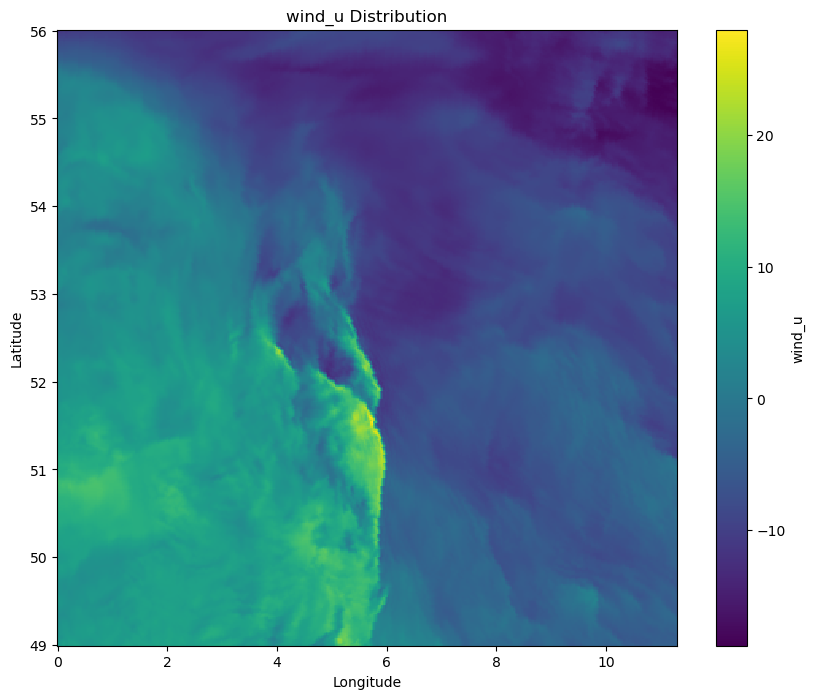

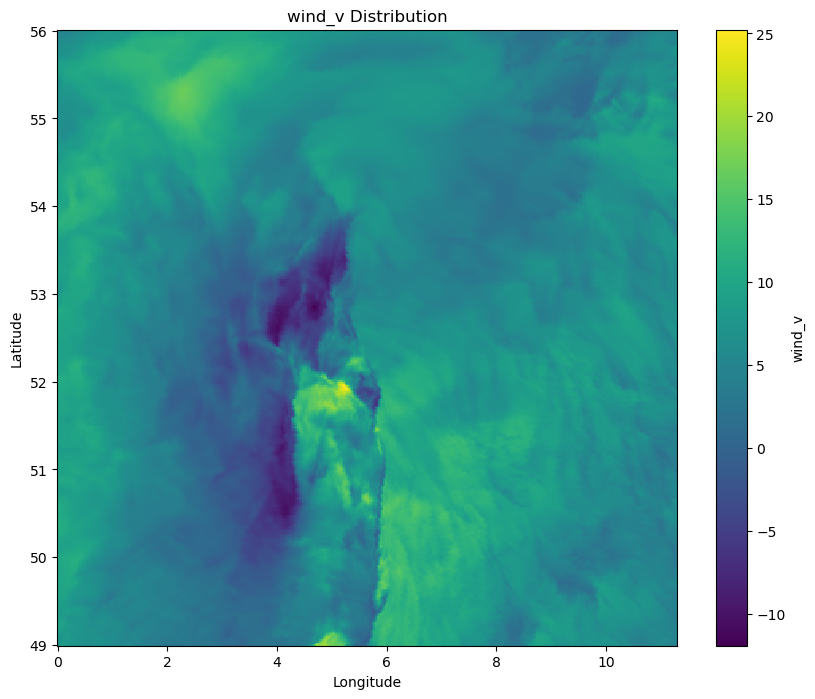

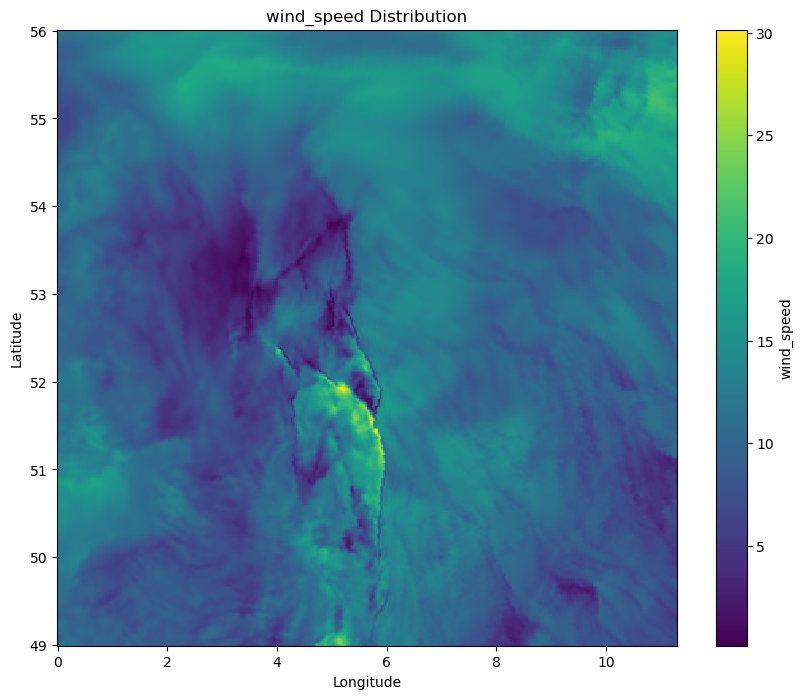

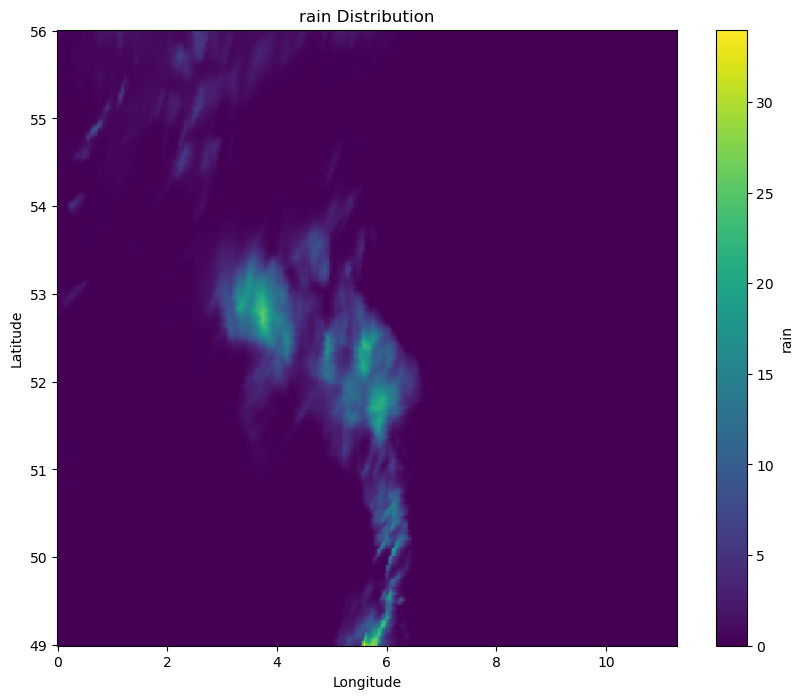

In [33]:
# 使用示例
# Example usage
grib_path = "HARMONIE_AROME_meteo_24hrs/extracted_merged"
hour = 7  # Starting hour

# Initialize extractor
extractor = GribDataExtractor(grib_path, hour)

# Test coordinates (Amsterdam)
test_lat, test_lon = 52.3676, 4.9041
values = extractor.get_values_at_coords(test_lat, test_lon)

# Print results
print(f"\nWeather data at ({test_lat}, {test_lon}):")
for param, value in values.items():
    print(f"{param}: {value}")

# Plot all layers
for layer in ['wind_u', 'wind_v', 'wind_speed', 'rain']:
    extractor.plot_layer(layer)